In [339]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.convolution import Gaussian2DKernel, convolve

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats # delete if not needed - see locate point sources cell

In [340]:
LINUX_DIRECTORY = "/home/aimee/mphys"
FIGURE_SAVEDIR = "figures"


In [341]:
# create GDIGS mosaic - from jg_notebooks/gp_plotting.ipynb

GDIGS_maps_dir = f"{LINUX_DIRECTORY}/data/GDIGS_moment0"

GDIGS_fnames = {
    "GDIGS G017.50":"GDIGS_G017.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G022.50":"GDIGS_G022.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G027.25":"GDIGS_G027.25+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G030.80":"GDIGS_G030.80+00.00_halpha_2pol_average_moment0.fits"
               }

GDIGS_keys = list(GDIGS_fnames.keys())

paths = []
for key in GDIGS_keys:
    paths.append(f"{GDIGS_maps_dir}/{GDIGS_fnames[key]}")

GDIGS_rawfits = [fits.open(path)[0] for path in paths]

mosaics = [(rawfit.data, rawfit.header) for rawfit in GDIGS_rawfits]

mosaic_WCS, shape = find_optimal_celestial_wcs(mosaics)

mosaic, _mosaic_ftprint = reproject_and_coadd(
    mosaics,
    output_projection = mosaic_WCS,
    shape_out = shape,
    reproject_function = reproject_interp,
    combine_function = "mean"
)

# prevents area outside mosaic from being plotted
mosaic[mosaic == 0.0] = np.nan
# print(paths)



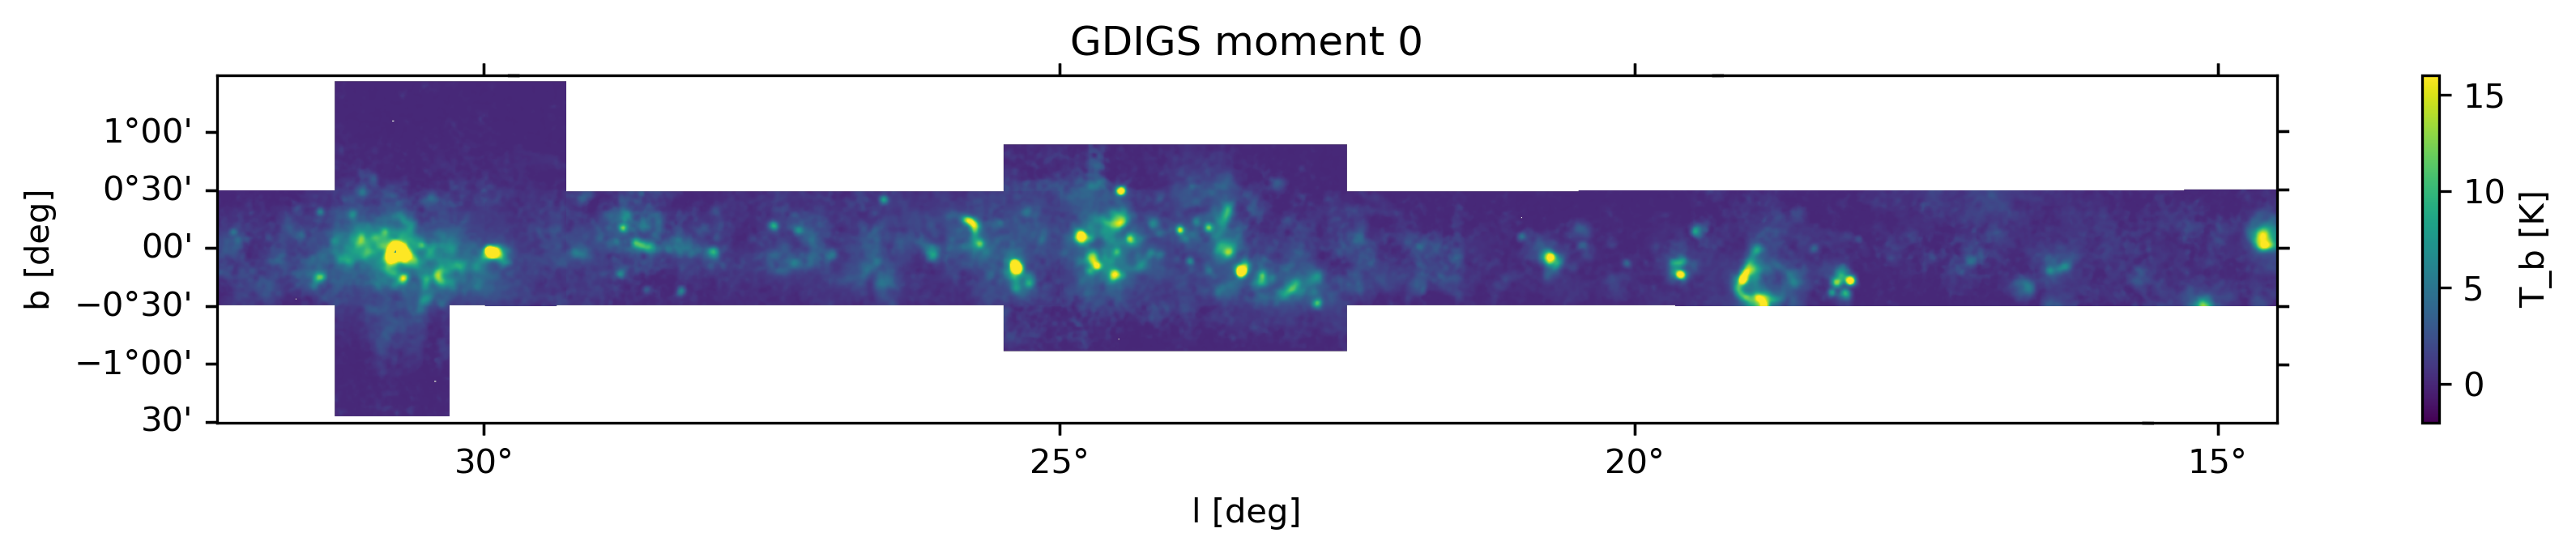

In [342]:
# Plot GDIGS mosaic - from jg_notebooks/gp_plotting.ipynb

fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                        subplot_kw={'projection': mosaic_WCS})

im = ax.imshow(mosaic, origin='lower', cmap='viridis', vmin = -2, vmax = 16)
ax.set_title("GDIGS moment 0")
ax.set_xlabel(r"l [deg]")
ax.set_ylabel(r"b [deg]")

cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("T_b [K]")

fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)

plt.savefig(f"{LINUX_DIRECTORY}/figures/GDIGS_moment0_mosaic.png", dpi=300)
plt.tight_layout()
plt.show()


In [343]:
# Locate point sources

# CHECK - what is std? of whole file or of bg? - or noise from fits file 1/file[3] for COMAP - check for GDIGS)

# estimate mean, median, std of background
mean, median, std = sigma_clipped_stats(mosaic, sigma=3.0) 
print(f'Mean bg = {mean}\nMedian bg = {median}\nStd of bg = {std}')

# # OR calculate std of whole image
# std = np.std(mosaic)
# median = 0 # no bgsub
# print(f'std of whole image: {std}')
# print(f'Std of mosaic: {std}')

fwhm_ps = 3.0
daofind =  DAOStarFinder(fwhm = fwhm_ps, threshold = 1*std) # TWEAK
sources = daofind(mosaic - median)

if sources:
    print(f'\nNo. sources identified: {len(sources)}')
    # print(sources)
    x_coords = sources['xcentroid']
    y_coords = sources['ycentroid']
else:
    x_coords = []
    y_coords = []

print(x_coords)
print(y_coords)


Mean bg = 1.0388732139061148
Median bg = 0.8103399947285652
Std of bg = 0.9105717325896214

No. sources identified: 45
    xcentroid     
------------------
 1149.506483434381
1597.8251153967171
1611.7745075867106
1701.4447863701157
1687.6376487722682
 484.7245883738353
1692.7149196718403
 1706.506228495553
1594.4597799525197
 194.1077848103648
               ...
 1006.142738669997
 423.8397056876028
1036.0744004183068
 581.4741876740043
 942.6865298907621
 788.1436739922285
 787.3356569545718
107.40960219049097
 696.4511647579454
 944.3943129323477
Length = 45 rows
    ycentroid     
------------------
123.72517102818318
129.99590149475168
128.32169357359976
133.76370170698766
134.78724712095377
136.21793013955534
145.70991254012014
 147.1969264902277
148.68471983785474
 149.5449941079631
               ...
200.03244799405982
202.29095663621933
 202.5268146931637
 204.3830640815681
207.93547997207912
207.41463327512042
 208.5996326679169
 218.7566673705954
231.64893008670273
 240.8694

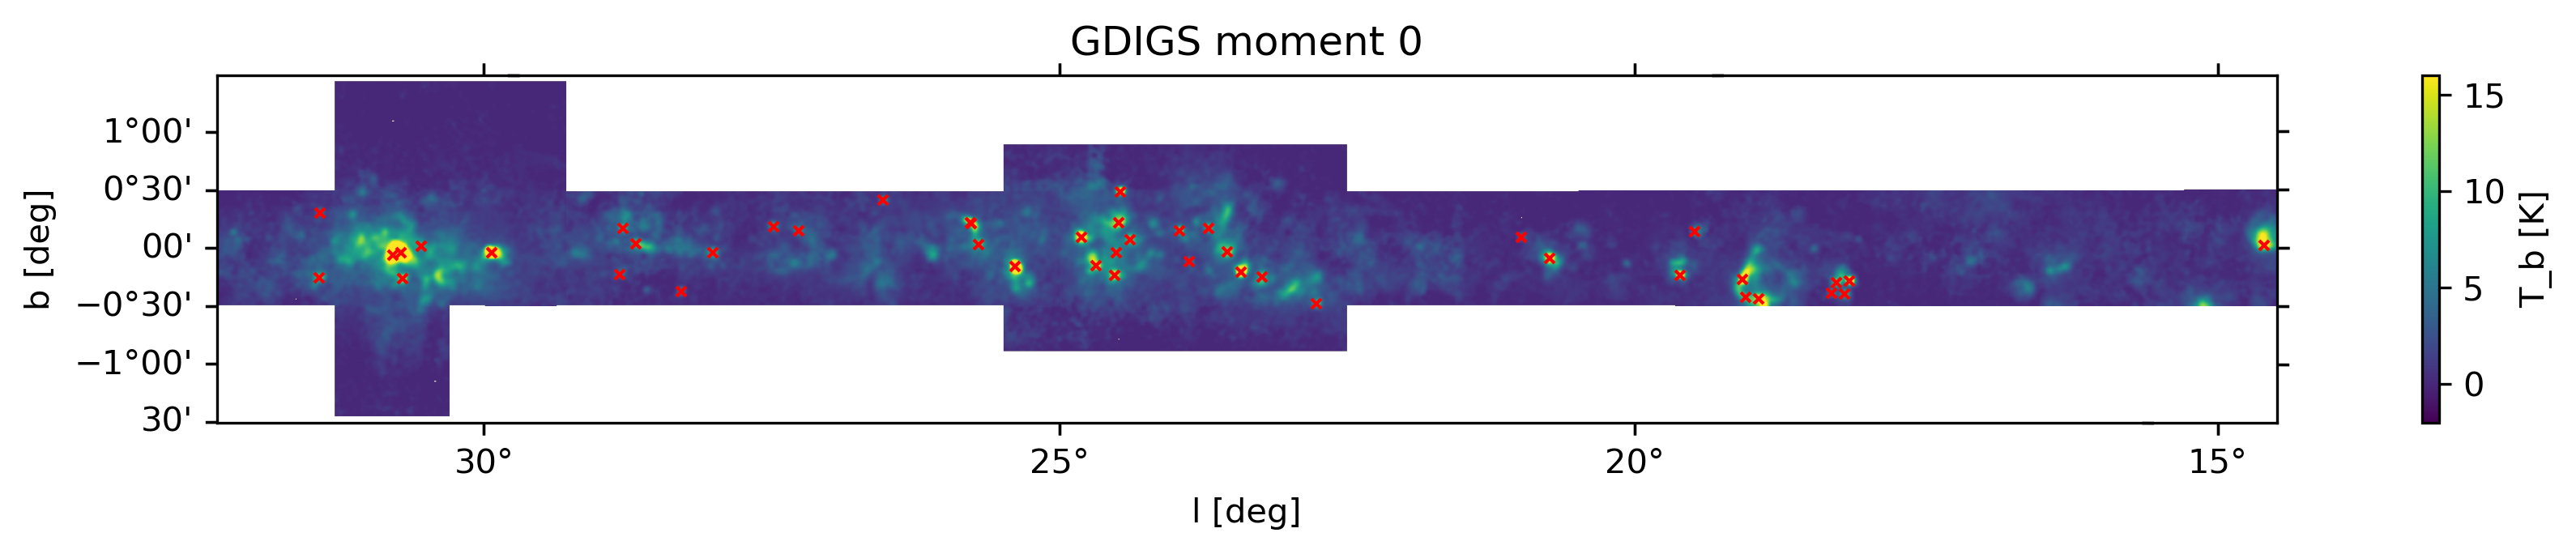

In [344]:
# Plot GDIGS mosaic with point sources 

fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                        subplot_kw={'projection': mosaic_WCS})
im = ax.imshow(mosaic, origin='lower', cmap='viridis', vmin = -2, vmax = 16)

ax.plot(x_coords, y_coords, 'rx', markersize=3) # plot point source locations on GDIGS mosaic map

ax.set_title("GDIGS moment 0")
ax.set_xlabel(r"l [deg]")
ax.set_ylabel(r"b [deg]")

cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("T_b [K]")

fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)

plt.savefig(f"{LINUX_DIRECTORY}/figures/GDIGS_moment0_mosaic_ps.png", dpi=300)
plt.tight_layout()
plt.show()

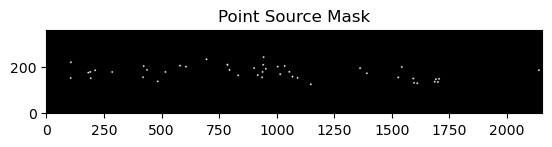

In [345]:
# Create point source mask

# Calculate sigma from FWHM
sigma = fwhm_ps / (2 * np.sqrt(2 * np.log(2)))

# Create meshgrid corresponding to image coords
y, x = np.indices(mosaic.shape)

# Create mask
mask_ps = np.zeros(mosaic.shape, dtype=bool) # empty, same shape as GDIGS mosaic
for x_c, y_c in zip(x_coords, y_coords):
    distance = np.sqrt((x - x_c)**2 + (y - y_c)**2) 
    mask_ps = np.logical_or(mask_ps, distance < 3*sigma)  # if pixel is < 3*sigma away from centre of point source (i.e. inside Gaussian), mask it

# Show mask (simple)
plt.imshow(mask_ps, origin='lower', cmap='gray')
plt.title('Point Source Mask')
plt.show()



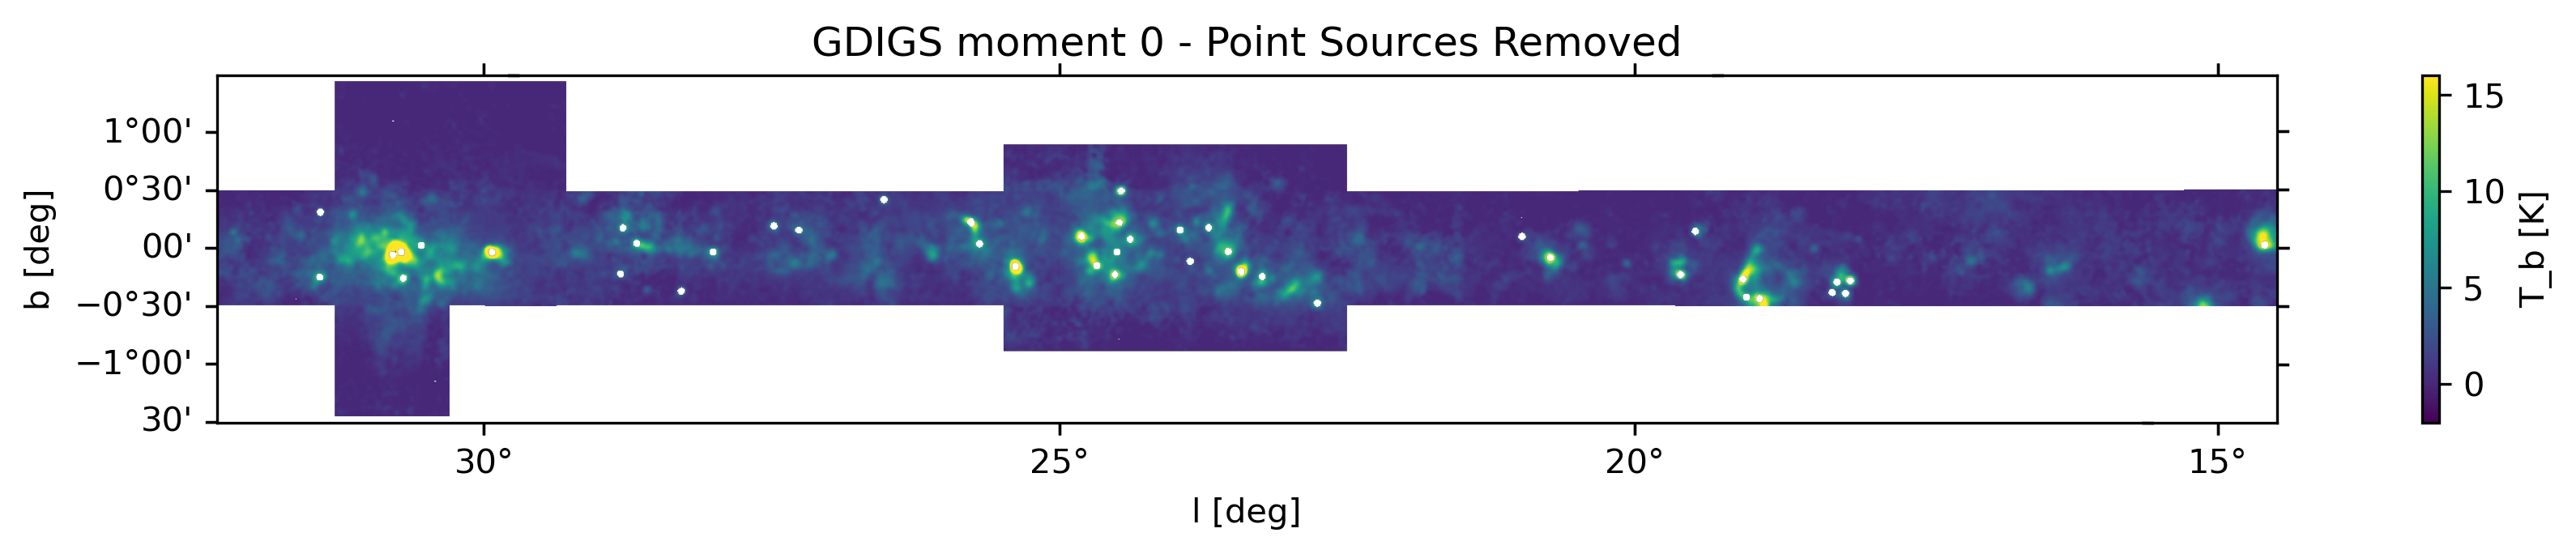

In [346]:
# Apply point source mask to GDIGS and plot

mosaic[mask_ps] = np.nan # change to hp.UNSEEN?

fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                        subplot_kw={'projection': mosaic_WCS})

im = ax.imshow(mosaic, origin='lower', cmap='viridis', vmin = -2, vmax = 16)
ax.set_title("GDIGS moment 0 - Point Sources Removed")
ax.set_xlabel(r"l [deg]")
ax.set_ylabel(r"b [deg]")

cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("T_b [K]")

fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)

plt.savefig(f"{LINUX_DIRECTORY}/figures/GDIGS_moment0_mosaic_ps_removed.png", dpi=300)
plt.tight_layout()
plt.show()

In [347]:
# Get SNR data
# From D. A. Green SNR Catalogue: https://www.mrao.cam.ac.uk/surveys/snrs/snrs.data.html

file_path = f'{LINUX_DIRECTORY}/data/SNR_Catalogue_DAGreen.txt'

x_coords = [] # galactic coords - l
y_coords = [] # galactic coords - b
diameters = [] # arcmin (diameter, not radius - see documentation on website)

with open(file_path, 'r') as file:
    for i, line in enumerate(file):
        if i > 2: # skip headers
            arr = line.split()
            # print(arr)
            
            diameter = arr[7] # either one number for both axes, or e.g. 4x6 for x and y axes
            
            # # Remove any lines w/ uncertain sizes (w/ question mark)
            # if '?' in diameter:
            #     print(f'Line {i} contains uncertain value - skipping line')
            #     continue
            # OR include and just strip ? from line
            diameter = diameter.replace('?', '')
            
            try:
                diameter = (float(diameter), float(diameter)) # x and y the same
            except ValueError:
                temp = diameter.split('x')
                diameter = (float(temp[0]), float(temp[1]))
            diameters.append(diameter)

            x_coords.append(float(arr[0]))
            y_coords.append(float(arr[1]))

print(x_coords) # galactic coords - l
print(y_coords) # galactic coords - b
print(diameters) # arcmin
            

[0.0, 0.3, 0.9, 1.0, 1.4, 1.9, 3.1, 3.7, 3.8, 4.2, 4.5, 4.8, 5.2, 5.4, 5.5, 5.9, 6.1, 6.1, 6.4, 6.4, 6.5, 7.0, 7.2, 7.5, 7.7, 8.7, 8.7, 8.9, 9.7, 9.8, 9.9, 11.0, 11.1, 11.1, 11.2, 11.4, 11.8, 12.0, 12.2, 12.5, 12.7, 12.8, 13.1, 13.3, 13.5, 14.1, 15.1, 15.4, 15.5, 15.9, 16.0, 16.2, 16.7, 17.0, 17.4, 17.4, 17.8, 17.8, 18.1, 18.6, 18.8, 18.9, 19.1, 20.0, 21.0, 21.5, 21.6, 21.8, 21.8, 22.7, 23.3, 24.7, 24.7, 25.1, 27.4, 27.8, 28.3, 28.6, 28.7, 28.8, 29.3, 29.6, 29.7, 30.7, 30.7, 31.5, 31.9, 32.0, 32.1, 32.4, 32.8, 33.2, 33.6, 34.7, 35.6, 36.6, 36.6, 38.7, 39.2, 39.7, 40.5, 41.1, 41.5, 42.0, 42.8, 43.3, 43.9, 45.7, 46.8, 49.2, 53.4, 53.6, 54.1, 54.4, 55.0, 55.7, 57.2, 59.5, 63.7, 64.5, 65.1, 65.3, 65.7, 66.0, 67.6, 67.7, 67.8, 68.6, 69.0, 69.7, 70.0, 73.9, 74.0, 74.9, 76.9, 78.2, 82.2, 83.0, 84.2, 85.4, 85.9, 89.0, 93.3, 93.7, 94.0, 96.0, 106.3, 107.0, 108.2, 109.1, 111.7, 113.0, 114.3, 116.5, 116.6, 116.9, 119.5, 120.1, 126.2, 127.1, 130.7, 132.7, 150.3, 152.4, 156.2, 159.6, 160.9, 166.0, 

WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-TAN' 'GLAT-TAN' 
CRVAL : 24.51356780678414 0.0 
CRPIX : 940.2205125729694 182.71998290803722 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00833333333333333 0.00833333333333333 
NAXIS : 0  0

Min, max l values: (14.5, 32)
Min, max y values: (-1.5, 1.5)
Min, max x values: (2153.2343573170583, 35.700920374043676)
Min, max y values: (-1.106215414794974, 363.3090293175493)

Transformed x coordinates: [array(2042.16612175), array(2029.86075139), array(1980.70658332), array(1968.4344683), array(1882.7047153), array(1846.05281744), array(1797.26194903), array(1712.07934544), array(1651.37921765), array(1627.13039852), array(1615.01237644), array(1590.7887272), array(1481.97184154), array(1361.37796356), array(1301.18248947), array(1289.15032456), array(1265.09233315), array(1156.92135873), array(1084.87043074), array(916.84857043), array(916.84857043), array(592.55533058), array(544.41557681), array(484.18602924), array(448.01548

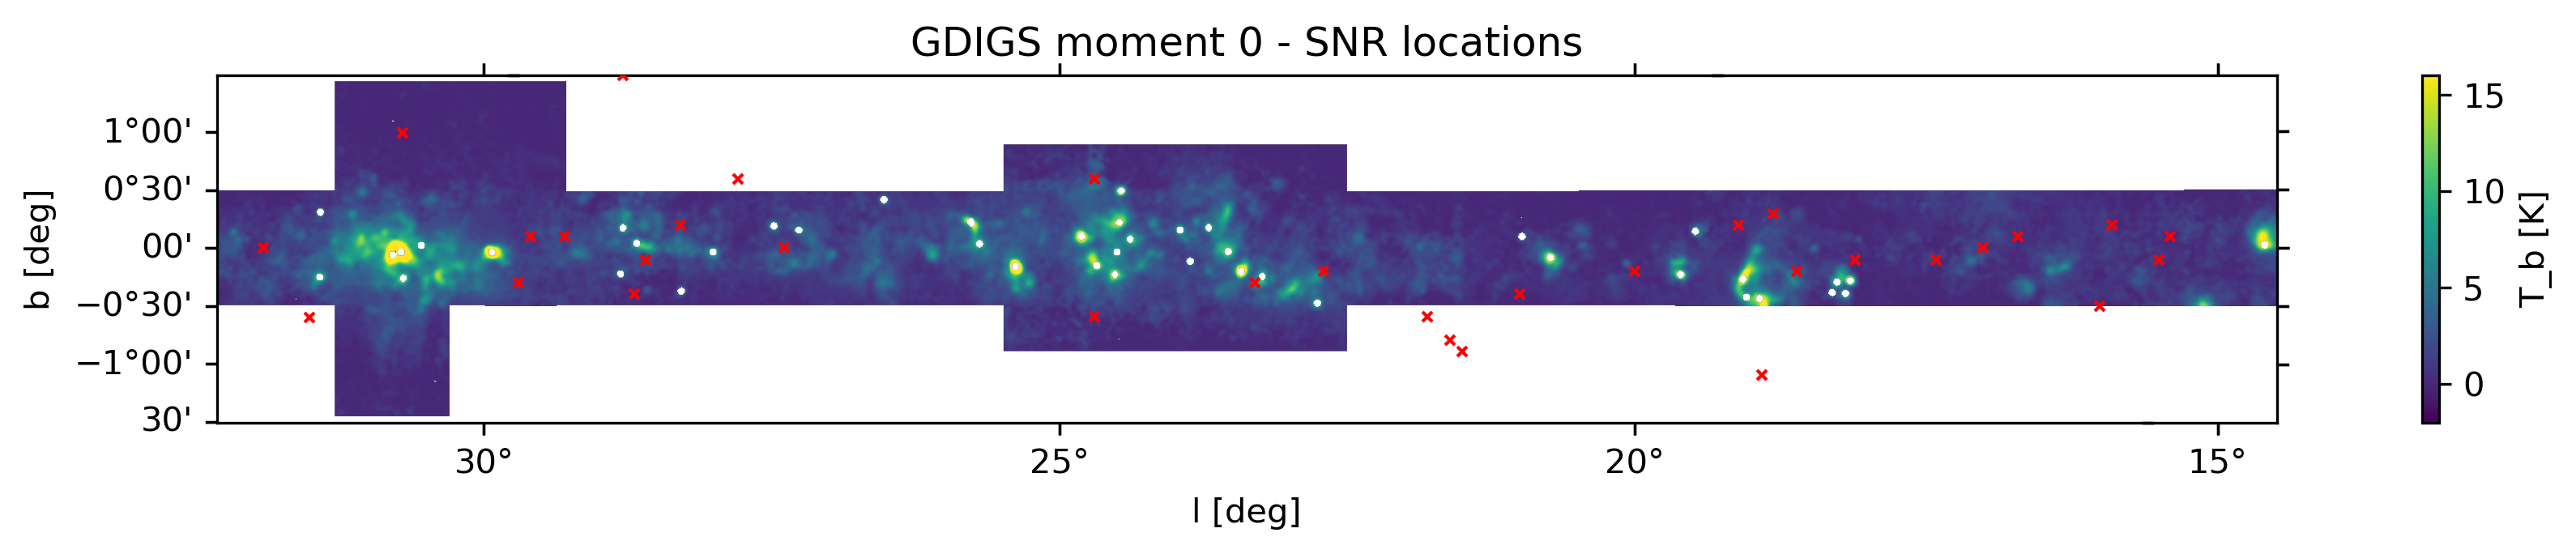

In [348]:
# Plot GDIGS mosaic with SNR locations 

# Convert x and y coordinates from galactic (l,b) to GDIGS coords
print(mosaic_WCS)

l_min = 14.5 # get actual values
l_max = 32
b_min = -1.5
b_max = +1.5

print(f'\nMin, max l values: ({l_min}, {l_max})\nMin, max y values: ({b_min}, {b_max})')

x_min, y_min = mosaic_WCS.all_world2pix(float(l_min), float(b_min), 0)
x_max, y_max = mosaic_WCS.all_world2pix(float(l_max), float(b_max), 0)

print(f'Min, max x values: ({x_min}, {x_max})\nMin, max y values: ({y_min}, {y_max})')

x_coords_new = []
y_coords_new = []
for i, _ in enumerate(x_coords):
    l = x_coords[i] 
    b = y_coords[i]
    x, y = mosaic_WCS.all_world2pix(float(l), float(b), 0)
    # print(x,y)
    # only append if in range
    if (x < x_min) & (x > x_max) & (y > y_min) & (y < y_max): # x inequalities flipped because axis reversed
        x_coords_new.append(x)
        y_coords_new.append(y)

print(f'\nTransformed x coordinates: {x_coords_new}')
print(f'Transformed y coordinates: {y_coords_new}')

fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                        subplot_kw={'projection': mosaic_WCS})
im = ax.imshow(mosaic, origin='lower', cmap='viridis', vmin = -2, vmax = 16)

ax.plot(x_coords_new, y_coords_new, 'rx', markersize=3) # plot SNR locations on GDIGS mosaic map

ax.set_title("GDIGS moment 0 - SNR locations")

ax.set_xlabel(r"l [deg]")
ax.set_ylabel(r"b [deg]")

cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("T_b [K]")

fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)

plt.savefig(f"{LINUX_DIRECTORY}/figures/GDIGS_moment0_mosaic_snr.png", dpi=300)
plt.tight_layout()
plt.show()

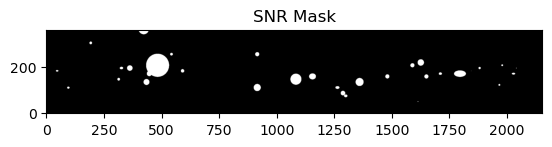

In [349]:
# Create SNR mask

# Create meshgrid corresponding to image coords
y, x = np.indices(mosaic.shape)

# Create mask
mask_snr = np.zeros(mosaic.shape, dtype=bool) # empty, same shape as GDIGS mosaic
for x_c, y_c, diameter_xy in zip(x_coords_new, y_coords_new, diameters):
    x_radius = diameter_xy[0]/2
    y_radius = diameter_xy[1]/2

    ellipse_condition = ((x - x_c) ** 2) / (x_radius ** 2) + ((y - y_c) ** 2) / (y_radius ** 2) <= 1
    mask_snr = np.logical_or(mask_snr, ellipse_condition) # if pixel within SNR ellipse, mask it
    

# Show mask (simple)
plt.imshow(mask_snr, origin='lower', cmap='gray')
plt.title('SNR Mask')
plt.show()




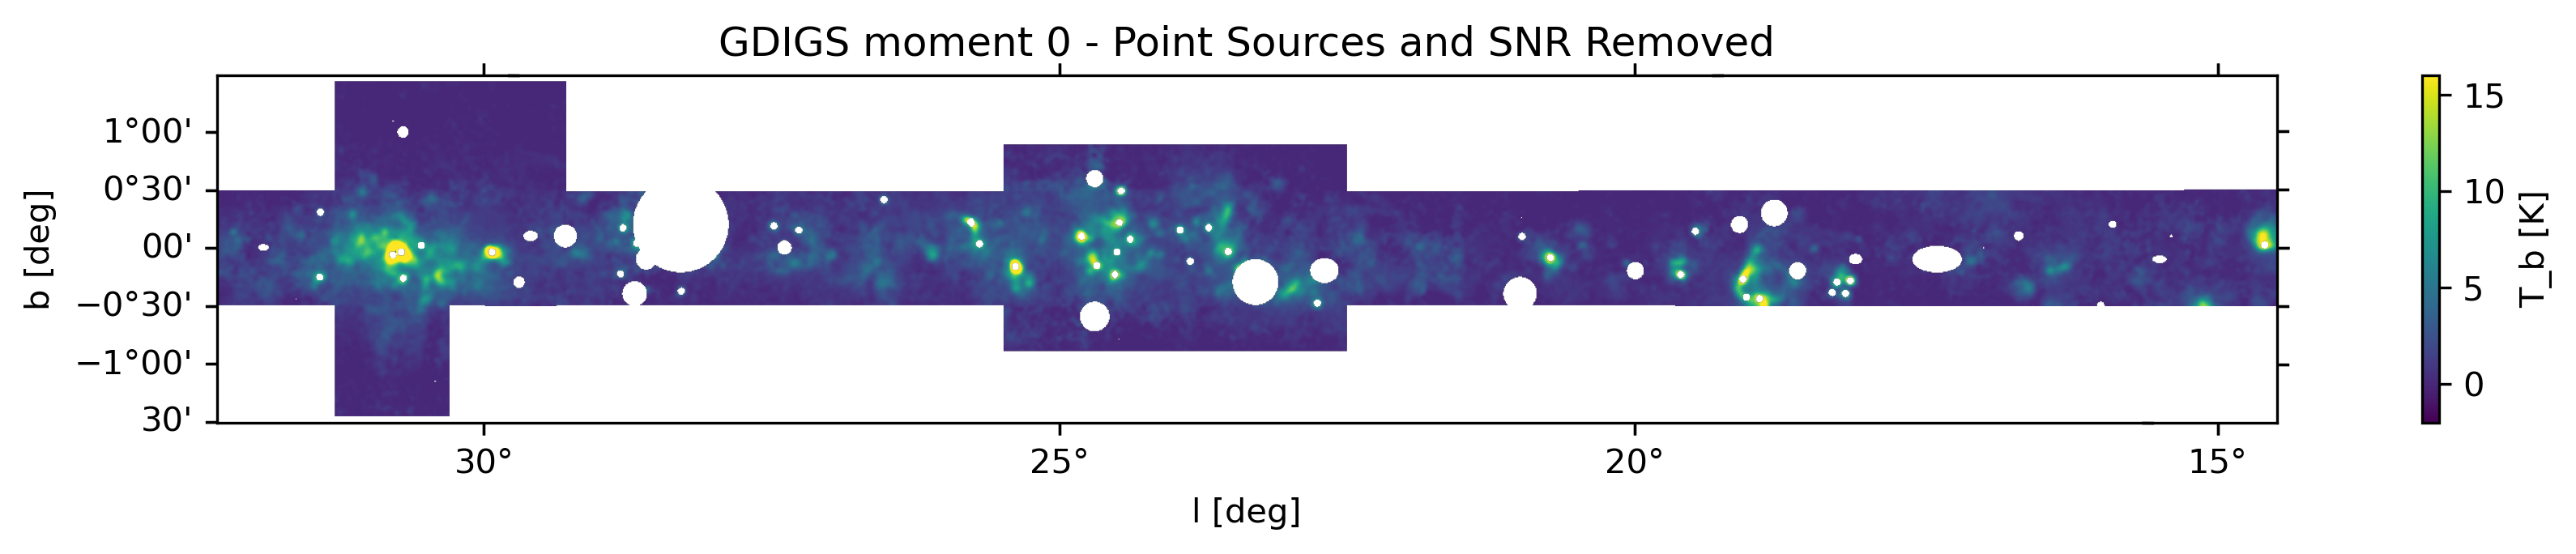

In [350]:
# Apply SNR mask and plot GDIGS with SNR (and point sources) removed

mosaic[mask_snr] = np.nan # change to hp.UNSEEN?

fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                        subplot_kw={'projection': mosaic_WCS})

im = ax.imshow(mosaic, origin='lower', cmap='viridis', vmin = -2, vmax = 16)
ax.set_title("GDIGS moment 0 - Point Sources and SNR Removed")
ax.set_xlabel(r"l [deg]")
ax.set_ylabel(r"b [deg]")

cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("T_b [K]")

fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)

plt.savefig(f"{LINUX_DIRECTORY}/figures/GDIGS_moment0_mosaic_ps_snr_removed.png", dpi=300)
plt.tight_layout()
plt.show()